Target-> 

Section 1: Descriptive analysis
   - Total layoffs
   - Industries affected
   - Countries affected
   - Monthly trends
   - Top companies with layoffs

Section 2: Factor analysis
- Does company size matter?
- Does funding matter?
- Does stage matter?
- Which industry experiences the highest layoff severity?

Importing the libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Loading the dataset

In [3]:
df = pd.read_csv("tech_layoffs_til_2025.csv")
df.head()

,Nr,Company,Location_HQ,Region,USState,Country,Continent,Laid_Off,Date_layoffs,Percentage,Company_Size_before_Layoffs,Company_Size_after_layoffs,Industry,Stage,Money_Raised_in__mil,Year,latitude,longitude
0,1,Tamara Mellon,Los Angeles,other,California,USA,North America,20.0,2020-03-12,40.0,50.0,30.0,Retail,Series C,90.0,2020,34.053691,-118.242766
1,2,HopSkipDrive,Los Angeles,other,California,USA,North America,8.0,2020-03-13,10.0,80.0,72.0,Transportation,Unknown,45.0,2020,34.053691,-118.242766
2,3,Panda Squad,San Francisco,San Francisco Bay Area,California,USA,North America,6.0,2020-03-13,75.0,8.0,2.0,Consumer,Seed,1.0,2020,37.779259,-122.419329
3,4,Help.com,Austin,other,Texas,USA,North America,16.0,2020-03-16,100.0,16.0,0.0,Support,Seed,6.0,2020,30.271129,-97.743700
4,5,Inspirato,Denver,other,Colorado,USA,North America,130.0,2020-03-16,22.0,591.0,461.0,Travel,Series C,79.0,2020,39.739236,-104.984862


Understanding the data set
   - Checking shape (rows, columns)
   - Inspecting data types
   - Reading column descriptions

In [4]:
df.shape

(2412, 18)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2412 entries, 0 to 2411
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Nr                           2412 non-null   int64  
 1   Company                      2412 non-null   object 
 2   Location_HQ                  2412 non-null   object 
 3   Region                       2412 non-null   object 
 4   USState                      2411 non-null   object 
 5   Country                      2412 non-null   object 
 6   Continent                    2412 non-null   object 
 7   Laid_Off                     2040 non-null   float64
 8   Date_layoffs                 2412 non-null   object 
 9   Percentage                   1963 non-null   float64
 10  Company_Size_before_Layoffs  1769 non-null   float64
 11  Company_Size_after_layoffs   1857 non-null   float64
 12  Industry                     2412 non-null   object 
 13  Stage             

Checking the Null values

In [3]:
df.isnull().sum() 

Nr                               0
Company                          0
Location_HQ                      0
Region                           0
USState                          1
Country                          0
Continent                        0
Laid_Off                       372
Date_layoffs                     0
Percentage                     449
Company_Size_before_Layoffs    643
Company_Size_after_layoffs     555
Industry                         0
Stage                          164
Money_Raised_in__mil           364
Year                             0
latitude                         0
longitude                        0
dtype: int64

Since USState only have one null value, we can safely drop that row

In [11]:
df.dropna(subset=['USState'], inplace = True)

Investigating the layoffs and percentage

In [26]:
df[['Laid_Off', 'Percentage']].isnull().sum()

Laid_Off      372
Percentage    449
dtype: int64

Total null values  in Laid_off = 372

Total null values in Percentage = 449


In [27]:
df[df['Laid_Off'].isnull() & df['Percentage'].isnull()].shape

(165, 19)

Insights
   - Rows where BOTH (Laid_off and percentage) are null = 165
   - Null values in Laid_off which have corresponding percentage values is 207 rows (372-165 = 207)


Therefore, we can safely remove those rows, which have null values in both percentage and layoff, as they aren't providing any meaningful information. (165) 

In [ ]:
df = df.dropna(subset=['Laid_Off', 'Percentage'], how='all')


In [51]:
df.reset_index(drop=True, inplace=True)

In [52]:
df[df['Laid_Off'].isnull() & df['Percentage'].isnull()].shape

(0, 17)

We cannot compute mean/median/mode in place of null values in layoff because that will create fake data

Checking for duplicates

In [48]:
df.duplicated().sum()

np.int64(5)

In [ ]:
df.drop_duplicates(inplace=True)  #Duplicates were removed

Verifying the Datatypes

In [ ]:
df.info()

Handling wrong datatype

In [ ]:
df['Date_layoffs'] = pd.to_datetime(df['Date_layoffs'], format='mixed', dayfirst=False)
df.info()

Engineering new features for time

In [55]:
df['Year_layoff'] = df['Date_layoffs'].dt.year
df['Month_layoff'] = df['Date_layoffs'].dt.month
df.head()

,Company,Location_HQ,Region,USState,Country,Continent,Laid_Off,Date_layoffs,Percentage,Company_Size_before_Layoffs,Company_Size_after_layoffs,Industry,Stage,Money_Raised_in__mil,Year,latitude,longitude,Year_layoff,Month_layoff
0,Tamara Mellon,Los Angeles,other,California,USA,North America,20.0,2020-03-12,40.0,50.0,30.0,Retail,Series C,90.0,2020,34.053691,-118.242766,2020,3
1,HopSkipDrive,Los Angeles,other,California,USA,North America,8.0,2020-03-13,10.0,80.0,72.0,Transportation,Unknown,45.0,2020,34.053691,-118.242766,2020,3
2,Panda Squad,San Francisco,San Francisco Bay Area,California,USA,North America,6.0,2020-03-13,75.0,8.0,2.0,Consumer,Seed,1.0,2020,37.779259,-122.419329,2020,3
3,Help.com,Austin,other,Texas,USA,North America,16.0,2020-03-16,100.0,16.0,0.0,Support,Seed,6.0,2020,30.271129,-97.743700,2020,3
4,Inspirato,Denver,other,Colorado,USA,North America,130.0,2020-03-16,22.0,591.0,461.0,Travel,Series C,79.0,2020,39.739236,-104.984862,2020,3


Now that we don't have duplicates, we can check for outliers

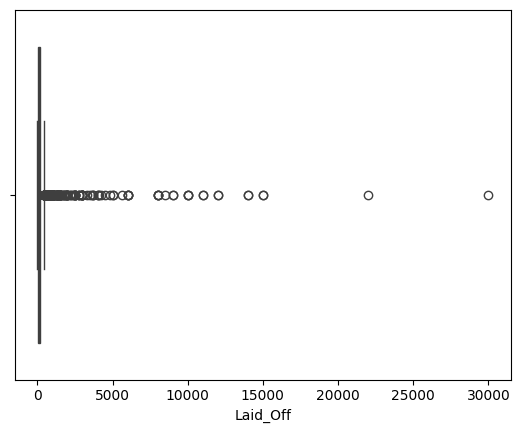

In [56]:
sns.boxplot(x = df["Laid_Off"])
plt.show()

These outliers cannot be removed as large layoffs are the genuine numbers and not errors.

PHASE-2 EDA

In [59]:
total_layoff = df['Laid_Off'].sum()
print(f'Total layoff: {total_layoff}' )
avg_layoff = df['Laid_Off'].mean()
print(f'Average layoff: {avg_layoff}' )

Total layoff: 745407.0
Average layoff: 366.4734513274336


Yearly total number of layoffs happening: Year_layoff
2020     61610.0
2021      6790.0
2022    127812.0
2023    179128.0
2024    170322.0
2025    199745.0
Name: Laid_Off, dtype: float64


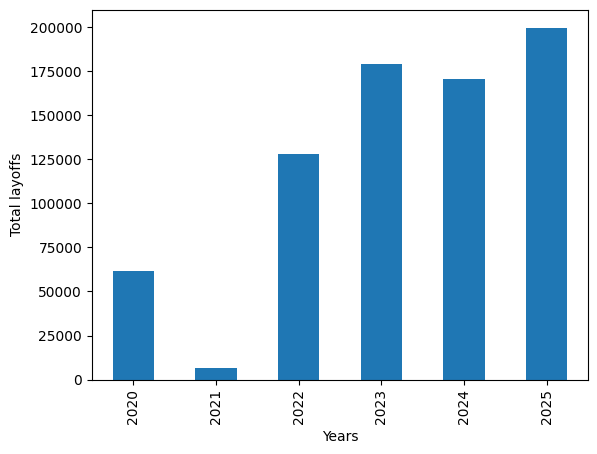

In [63]:
yearly = df.groupby("Year_layoff")['Laid_Off'].sum()
print(f'Yearly total number of layoffs happening: {yearly}')
yearly.plot(kind='bar')
plt.xlabel("Years")
plt.ylabel("Total layoffs") 
plt.savefig('Layoffs by Year.png')

Insights 
   - Total layoff: 745407.0
   - Average layoff: 366.4734513274336
   - In year 2025, maximum layoffs were seen, while in 2021 minimum layoffs were seen

Monthly total number of layoffs happening: Month_layoff
1     103839.0
2      61059.0
3      57740.0
4     100600.0
5      64114.0
6      44332.0
7      55108.0
8      54637.0
9      32234.0
10     52943.0
11    100339.0
12     18462.0
Name: Laid_Off, dtype: float64


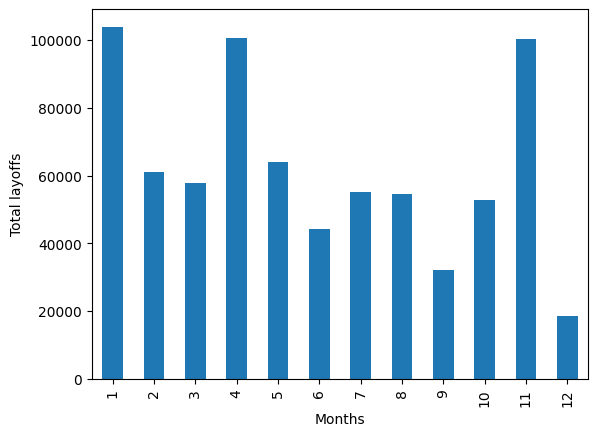

In [65]:
monthly = df.groupby('Month_layoff')['Laid_Off'].sum()
print(f'Monthly total number of layoffs happening: {monthly}')
monthly.plot(kind='bar')
plt.xlabel("Months")
plt.ylabel("Total layoffs") 
plt.savefig('Layoffs by Month.png')


Insights
   - In month of January, maximum layoffs were seen, while in December least layoffs were seen
   - In the months from May to October there was minimal up and down in the layoff
   - In the month of January, April and November a spike was seen 

Monthly total number of layoffs happening in 2025: Month_layoff
1      2807.0
2     15830.0
3      9125.0
4     24545.0
5     10397.0
6      1306.0
7     29066.0
8      8956.0
9     21340.0
10    34124.0
11    40638.0
12     1611.0
Name: Laid_Off, dtype: float64


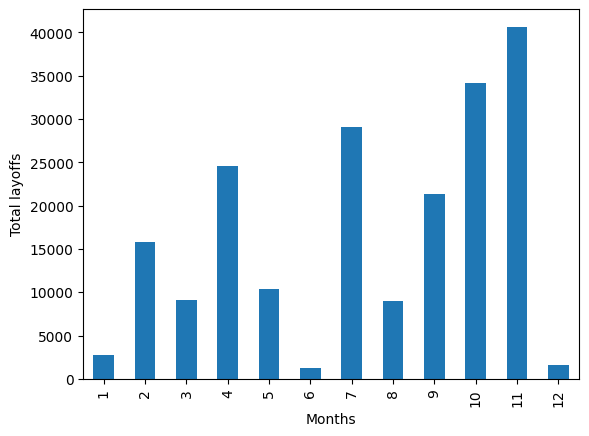

In [68]:
Year_2025 = df[df['Year_layoff'] == 2025].groupby("Month_layoff")["Laid_Off"].sum()
print(f'Monthly total number of layoffs happening in 2025: {Year_2025}')
Year_2025.plot(kind='bar')
plt.xlabel("Months")
plt.ylabel("Total layoffs") 
plt.savefig('Layoffs in 2025.png')


Insights 
   - In 2025, in the month of november, maximum layoffs had happened
   - In 2025, in the month of January, June and December least layoffs were seen


Industry
Consumer                            65642.0
Retail                              62190.0
Hardware                            60842.0
Other                               57891.0
Software Development                43634.0
Transportation                      42980.0
Finance                             42436.0
Food                                39006.0
E-commerce                          30874.0
IT Services and IT Consulting       22066.0
Motor Vehicle Manufacturing         20020.0
Healthcare                          17295.0
Infrastructure                      16838.0
Real Estate                         16339.0
Sales                               16076.0
HR                                  15381.0
Telecommunication                   15000.0
Travel                              12661.0
Education                           12022.0
Business Consulting and Services    11560.0
Name: Laid_Off, dtype: float64


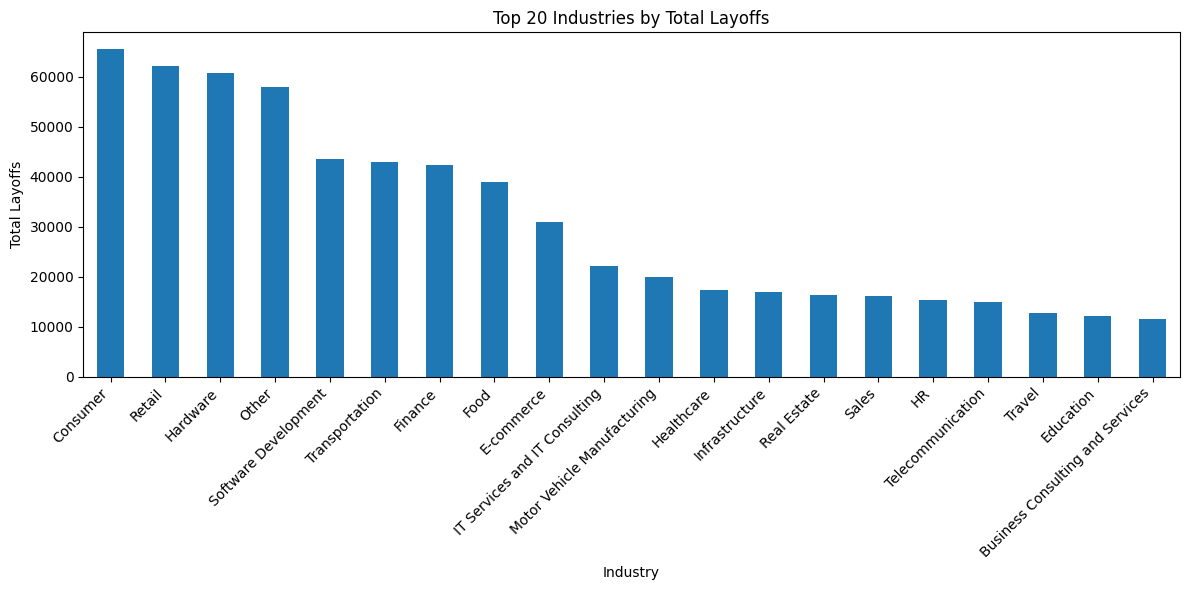

<Figure size 640x480 with 0 Axes>

In [ ]:
industry_layoffs = (df.groupby("Industry")["Laid_Off"].sum().sort_values(ascending=False).head(20))
plt.figure(figsize=(12,6))

industry_layoffs.plot(kind="bar")
plt.title("Top 20 Industries by Total Layoffs")
plt.ylabel("Total Layoffs")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
plt.savefig("Top 20 Industries by Total Layoffs.png")

Insights: 
   - Consumer industry was most affected by layoffs
   - Healthcare, Infrastructure, Real Estate, Sales, HR, Telecommunication, Travel, Education and Business Consulting and Services maintained almost same number of layoffs

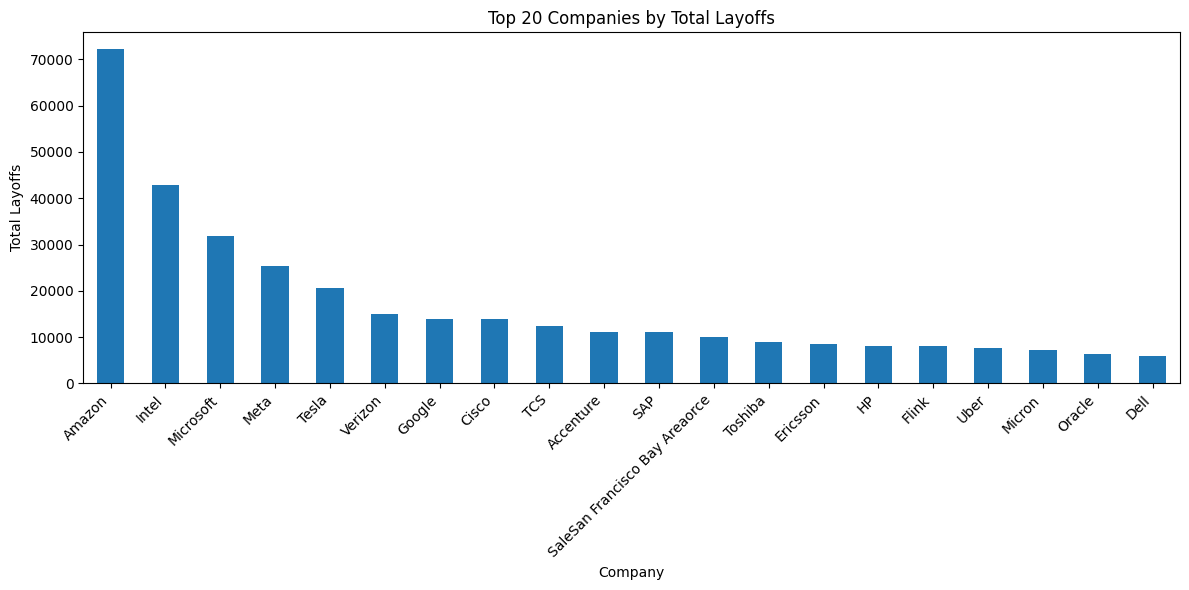

<Figure size 640x480 with 0 Axes>

In [84]:
company = (df.groupby('Company')['Laid_Off'].sum().sort_values(ascending=False)).head(20)

plt.figure(figsize=(12,6))
company.plot(kind="bar")
plt.title("Top 20 Companies by Total Layoffs")
plt.ylabel("Total Layoffs")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
plt.savefig("Top 20 Companies by Total Layoffs.png")

Insights
  -  Company with the maximum layoffs is Amazon
  - Companies like Toshiba, Ericsson, HP, Flink, Uber, Micron, Oracle and Dell maintained almost same number of layoffs

Countries affected by layoffs: Country
USA                        541152.0
India                       55212.0
Germany                     28933.0
Sweden                      17201.0
UK                          17078.0
Canada                      14195.0
Israel                      13300.0
Ireland                     12191.0
Japan                        9298.0
Brazil                       7029.0
Singapore                    5316.0
Indonesia                    4291.0
Australia                    3164.0
Kenya                        2042.0
China                        1825.0
Nigeria                      1290.0
France                       1189.0
United Arabian Emirates      1088.0
Netherlands                  1030.0
New Zealand                  1025.0
Name: Laid_Off, dtype: float64


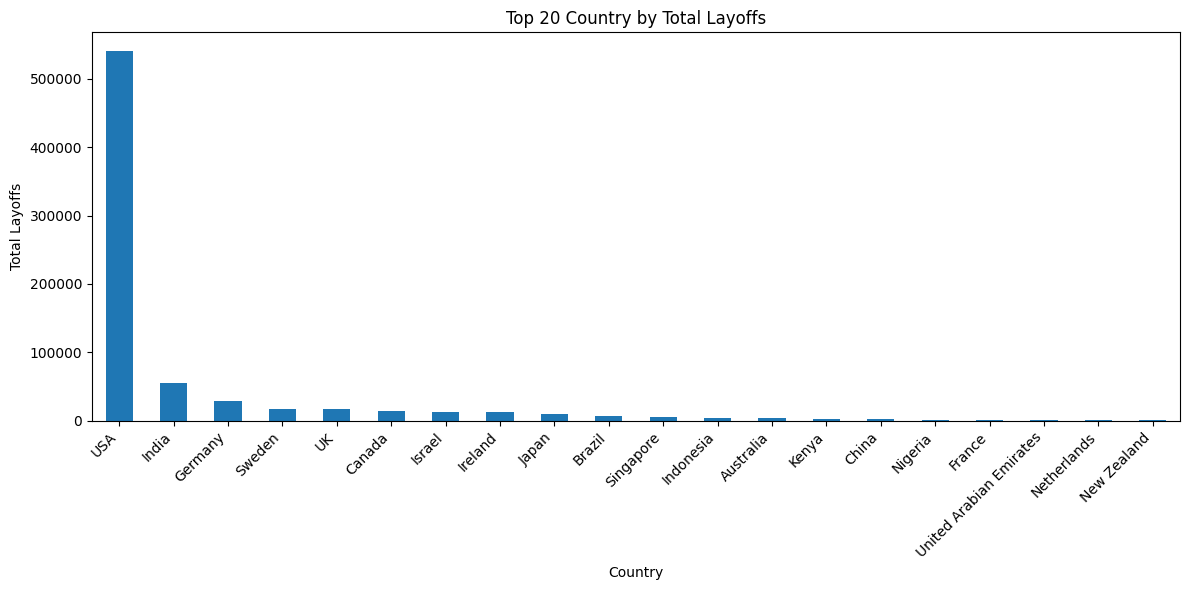

<Figure size 640x480 with 0 Axes>

In [87]:
Country = (df.groupby('Country')['Laid_Off'].sum().sort_values(ascending=False)).head(20)
print(f'Countries affected by layoffs: {Country}')
plt.figure(figsize=(12,6))
Country.plot(kind="bar")
plt.title("Top 20 Country by Total Layoffs")
plt.ylabel("Total Layoffs")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
plt.savefig("Top 20 Country by Total Layoffs.png")

Insights
  - Country with the maximum layoffs is USA
  - Countries like Kenya, China, Nigeria, France, UAE, Netherlands and New Zealand maintained almost negligible number of layoffs

States in th USA affected by layoffs: USState
California              273294.0
Washington              116330.0
New York                 48862.0
Texas                    31944.0
Massachusetts            18056.0
Illinois                  8490.0
Idaho                     7200.0
Arizona                   5019.0
Pennsylvania              4123.0
Florida                   4086.0
Oregon                    3883.0
Connecticut               3720.0
Utah                      2546.0
Colorado                  2267.0
Georgia                   2184.0
Ohio                      1620.0
North Carolina            1466.0
Michigan                  1378.0
District of Columbia       947.0
Oklahoma                   500.0
Name: Laid_Off, dtype: float64


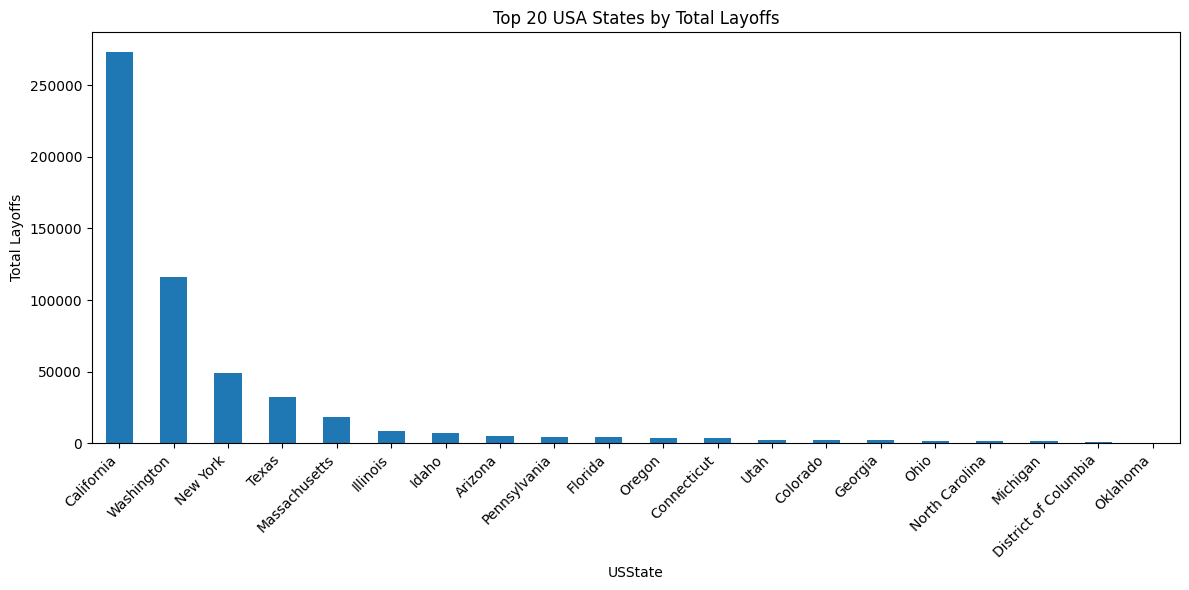

<Figure size 640x480 with 0 Axes>

In [92]:
USA = df[df['Country'] == "USA"].groupby("USState")['Laid_Off'].sum().sort_values(ascending=False).head(20)
print(f'States in th USA affected by layoffs: {USA}')
plt.figure(figsize=(12,6))
USA.plot(kind="bar")
plt.title("Top 20 USA States by Total Layoffs")
plt.ylabel("Total Layoffs")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
plt.savefig("Top 20 USA States by Total Layoffs.png")


Insights
  - USA State with the maximum layoffs is California
  - States like Utah, Colorado, Georgia, Ohio, North Carolina, Michigan, District of Columbia and Oklahoma maintained almost negligible number of layoffs

FINAL INSIGHTS FOR SECTION-1

Section 1: Descriptive analysis
   - Total layoffs-> 745407.0
--------------------------------------------------------------------------------------------------------------------------------
   - Industries affected (Most)-> Consumer->  65642.0
   - Industries affected (Least)-> Business Consulting and Services->   11560.0
--------------------------------------------------------------------------------------------------------------------------------
   - Countries affected (Most)-> USA-> 541152.0
   - Countries affected (Least)-> New Zealand-> 1025.0
--------------------------------------------------------------------------------------------------------------------------------
   - USA States affected (Most)-> California-> 273294.0
   - USA States affected (Least)-> Oklahoma-> 500.0
--------------------------------------------------------------------------------------------------------------------------------
   - Monthly trends
   - Top companies with layoffs